# Nombre: Atzin Cruz

# Practica2: Bow

In [1]:
#Leer archivos

def get_texts_from_file(texts_path, labels_path):
    texts = []
    labels = []
    with open(texts_path, 'r', encoding='utf-8') as f_texts, open(labels_path, 'r', encoding='utf-8') as f_labels:
        for text_line, label_line in zip(f_texts, f_labels):
            texts.append(text_line.strip())
            labels.append(label_line.strip())
    return texts, labels

In [2]:
tr_text, tr_y = get_texts_from_file("./mex20_train.txt", "./mex20_train_labels.txt")

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline

Counter({'0': 3759, '1': 1519})


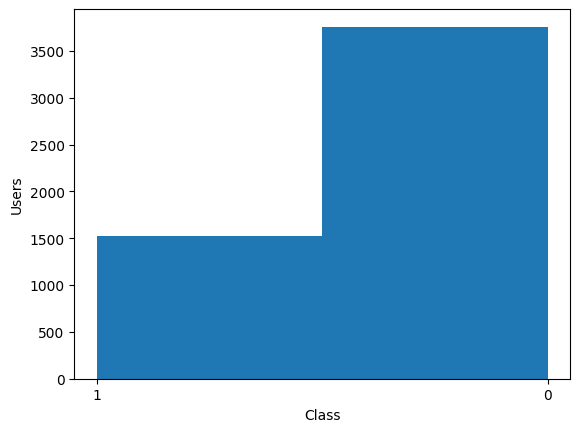

In [4]:
from collections import Counter

print(Counter(tr_y))

plt.hist(tr_y, bins = len(set(tr_y)))

plt.ylabel("Users")
plt.xlabel("Class")
plt.show()

In [5]:
tr_text[154].split()

['Ay',
 'putas',
 'igualito',
 '😒',
 'Siempre',
 'estoy',
 'ahí',
 'para',
 'todos.',
 'Nadie',
 'está',
 'ahí',
 'para',
 'mí.',
 'La',
 'historia',
 'de',
 'mi',
 'vida',
 '😣😞😔😭😠']

In [6]:
from nltk.tokenize import TweetTokenizer
tokenizer = TweetTokenizer()

In [7]:
tokenizer.tokenize(tr_text[154])

['Ay',
 'putas',
 'igualito',
 '😒',
 'Siempre',
 'estoy',
 'ahí',
 'para',
 'todos',
 '.',
 'Nadie',
 'está',
 'ahí',
 'para',
 'mí',
 '.',
 'La',
 'historia',
 'de',
 'mi',
 'vida',
 '😣',
 '😞',
 '😔',
 '😭',
 '😠']

# Tokenizar todo el corpus

In [8]:
import nltk

corpus_palabras = []

for doc in tr_text:
    corpus_palabras += tokenizer.tokenize(doc)

In [9]:
len(set(corpus_palabras))

15194

In [10]:
fdist = nltk.FreqDist(corpus_palabras)

In [11]:
fdist

FreqDist({',': 3016, 'de': 2915, 'que': 2829, '.': 2604, 'la': 2031, 'a': 1956, 'y': 1856, '!': 1435, 'no': 1430, '@USUARIO': 1399, ...})

In [12]:
def sortFreqDist(freqdict): 
    aux = [(freqdict[key], key)for key in freqdict]
    aux.sort()
    aux.reverse()
    return aux # se convierte en el diccionario

In [13]:
V = sortFreqDist(fdist)[:10000]

In [14]:
len(V)

10000

In [15]:
# Diccionario de Indices
dic_indices = dict() # dict_indices{PALABRA} = Indice en la bolsa de palabras, palabra mas frecuente 0

for i, word in enumerate(V):
    dic_indices[word[1]] = i

dic_indices

len(dic_indices)



10000

In [16]:
import numpy as np

def build_bow_tr(texts, V, dict_indices):
    import numpy as np
    BOW = np.zeros((len(texts), len(dict_indices)))
    cont_doc = 0
    
    for tr in texts:
        fdist_doc = nltk.FreqDist(tokenizer.tokenize(tr.lower()))
        for word in fdist_doc:
            if word in dict_indices:
                idx = dict_indices[word]
                BOW[cont_doc, idx] = fdist_doc[word]
        cont_doc += 1
    return BOW

def build_tfidf_tr(tr_txt, V, dict_indices): 

    N = len(tr_txt) # Número de documentos en el training
    TFIDF = np.zeros((N, len(V)), dtype=float)

    DF = np.zeros(len(V), dtype=float) # Vector que me dice para cada palabra en el vocabulario, cuantos documentos la contienen 

    # Calcular DF (Document Frequency)
    for doc in tr_txt: 
        palabras = tokenizer.tokenize(doc.lower()) # tokenizar
        palabras_unicas = set(palabras) 
        for w in palabras_unicas: 
            if w in dict_indices:
                DF[dict_indices[w]] += 1
                
    # Calcular IDF una sola vez después de tener todos los DF
    IDF = np.log((N+1)/(DF+1)) + 1 # Broad Casting
    
    # Calcular para cada tuit: TFIDF = TF * IDF
    for i, doc in enumerate(tr_txt): # Recorrer todos los documentos 
        fdist = nltk.FreqDist(tokenizer.tokenize(doc.lower())) # sacar palabras de cada tuit
        doc_len = len(fdist) # tamaño del documento
        for w, freq in fdist.items():
            if w in dict_indices: 
                TF = freq/doc_len # Frecuencia Normalizada 
                TFIDF[i,dict_indices[w]] = TF * IDF[dict_indices[w]] # combinación del pesado 
    return TFIDF


In [17]:
BOW_tr = build_tfidf_tr(tr_text, V, dic_indices)

In [18]:
from sklearn import preprocessing
BOW_tr = preprocessing.normalize(BOW_tr, norm='l2')

In [19]:
BOW_tr.shape

print(BOW_tr)

[[0.         0.1206922  0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.12281479 0.         ... 0.         0.         0.        ]
 ...
 [0.         0.09904877 0.         ... 0.         0.         0.        ]
 [0.15904699 0.         0.         ... 0.         0.         0.        ]
 [0.09011348 0.08463473 0.         ... 0.         0.         0.        ]]


In [20]:
val_text, val_y = get_texts_from_file("./mex20_val.txt", "./mex20_val_labels.txt")

Counter({'0': 418, '1': 169})


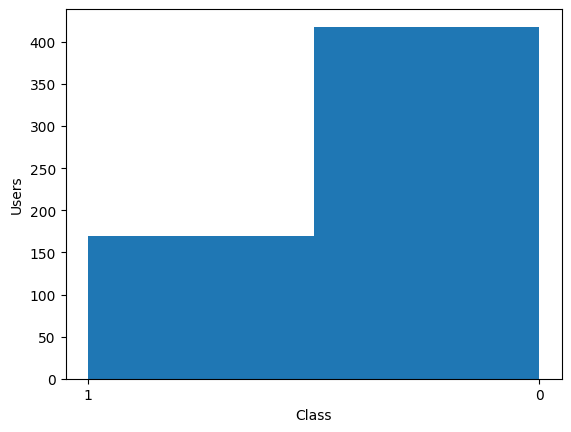

In [21]:
from collections import Counter

print(Counter(val_y))

plt.hist(val_y, bins = len(set(val_y)))

plt.ylabel("Users")
plt.xlabel("Class")
plt.show()

In [22]:
BOW_val = build_tfidf_tr(val_text, V, dic_indices)
BOW_val = preprocessing.normalize(BOW_val, norm='l2')

In [23]:
BOW_val.shape

(587, 10000)

# Clasificacion

In [24]:
tr_y = list(map(int, tr_y)) 
val_y = list(map(int, val_y)) 

from sklearn import svm
from sklearn.model_selection import GridSearchCV # Para varios experimentos y probar parametros
from sklearn import metrics
from sklearn.metrics import precision_recall_fscore_support

svm = svm.LinearSVC(class_weight='balanced') 

parameters = {'C': [.5, .12, .25, .5, 1, 2, 4]}
# varios experimentos a probar un parametro 
grid = GridSearchCV(estimator=svm, param_grid=parameters, n_jobs=4, scoring="f1_macro", cv=5 )

grid.fit(BOW_tr, tr_y) # llevar a cabo entrenamiento sobre la bolsa de palabras de TRAIN

y_pred = grid.predict(BOW_val)

In [25]:
print(metrics.classification_report(val_y, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.87      0.88       418
           1       0.70      0.76      0.73       169

    accuracy                           0.84       587
   macro avg       0.80      0.81      0.81       587
weighted avg       0.84      0.84      0.84       587



In [26]:

# Mostrar los tuits con clasificación erronea. Mostrar el texto de cada tuit, su etiqueta truth y su real
# Tu código va aquí.
incorrect = []
for i in range(len(val_y)):
    if val_y[i] != y_pred[i]:
        print(f"Tuit: {val_text[i]}")
        print(f"Etiqueta real: {val_y[i]}, Etiqueta predicha: {y_pred[i]}")
        incorrect.append(val_text[i])
        print("--------------------------------------------------")

Tuit: @USUARIO Entonces para que quieres estar en sus paises?, mejor vente aca y chinguele cabrona de verdad, maldita sangana.
Etiqueta real: 1, Etiqueta predicha: 0
--------------------------------------------------
Tuit: Que bueno que hoy juega México, porque tú vales verga, hija de la chingada.
Etiqueta real: 1, Etiqueta predicha: 0
--------------------------------------------------
Tuit: Acá culo dulcero y goloso putos y espantados, a c.a.s.
Etiqueta real: 0, Etiqueta predicha: 1
--------------------------------------------------
Tuit: Mejor que te regalen una buena cogida para que no idolatres a tanto joto de la radio
Etiqueta real: 1, Etiqueta predicha: 0
--------------------------------------------------
Tuit: En que pinche momento existieron los putos cólicos?! 😩 😩 😤 😤 #dolor
Etiqueta real: 0, Etiqueta predicha: 1
--------------------------------------------------
Tuit: Quiero ser de esos actores  que una vez le dijeron que eran malos y que nunca iban a ser buenos actores y bom

In [27]:
for error in incorrect:
    if "madre" in error.lower():
        print(error)

@USUARIO Ya m tienen hasta la madre esos maes
Amigos, Vero tiene toda la razón por eso no hay que ir a esa madre, mejor todos a Costeño a empedar.
PUTA MADRE, PORQUÉ A LAS MORRAS LE GUSTAN LOS VATOS PENDEJOS DROGOS Y NO LA GENTE CHIDA Y VERGAS? PUTAS MORRAS CAGAN &gt;:V
Ya van a ser las putas 8 y la pasarela no tiene para cuando empezar perra madre
Políticos pseudoaficiomados que sólo en finales hablan de beisbol pueden ir mucho a chingar a su madre. Y peor cuando opinan.
@USUARIO @USUARIO Hija de tu madre 😂😂😂😂🖕🏼🖕🏼🤚🏻
🎵🎵De mi parte vas y CHINGAS A TU MADRE @USUARIO 🎵🎵 Grande Tigre Sepúlveda. 🙌🏾🙌🏾
YAAAAA MADRE NATURALEZA BÁJALE A TU PEDO
La vida se pone tan chula como tu decidas que se te ponga....pontela poca madre!!!
La anciana madre de Freddie Mercury desmitifica a su hijo
@USUARIO No tienen abuela madre vergüenza....
Ni madre ps si lo que quiere es descansar de nosotras 😂😂😂😂😅🤣🤣🤣😅😅
Gallardo, ¿QUÉ PUTAS MADRES HACES JUGANDO FÚTBOL? No estás ni para utilero.


In [28]:
def build_bow_tr_tf(texts, V, dict_indices):
    import numpy as np
    BOW = np.zeros((len(texts), len(dict_indices)))
    cont_doc = 0
    
    for tr in texts:
        fdist_doc = nltk.FreqDist(tokenizer.tokenize(tr.lower()))
        for word in fdist_doc:
            if word in dict_indices:
                idx = dict_indices[word]
                BOW[cont_doc, idx] = 1/fdist_doc[word]
        cont_doc += 1
    return BOW

In [29]:
from wordcloud import WordCloud
texto ="""
La Universidad Panamericana es una universidad privada en la Ciudad de México de orientación católica, y fundada en 1967 como una escuela de negocios y relacionada al Opus Dei. Sus orígenes se encuentran en el Instituto Panamericano de Alta Dirección de Empresa (IPADE) que se convirtió, poco más tarde, en promotor de lo que hoy es la Universidad Panamericana. El Instituto Panamericano de Humanidades (IPH), predecesor inmediato de la Universidad Panamericana, nació en 1968. En 1978, el IPH fue elevado al rango de universidad, y tomó el nombre de Universidad Panamericana.

La Universidad Panamericana cuenta con tres campus y una sede. El primer campus se inauguró en la Ciudad de México en 1968, después Guadalajara en 1981 y Aguascalientes en 1989. La sede Santa Fe, también en la Ciudad de México, se inauguró en 2011, siendo una sola universidad, con un mismo espíritu. La Universidad Panamericana se apoya en tres pilares fundamentales: la enseñanza, la investigación y la difusión de la cultura. En virtud de un convenio establecido entre la Junta de Gobierno y la Prelatura del Opus Dei, la Universidad Panamericana ha confiado a dicha Prelatura la atención espiritual y la orientación doctrinal de sus actividades. Actualmente es la cuarta mejor universidad en México, según QS World University Rankings[1]​ y la segunda mejor universidad privada.


Antiguo obraje de Mixcoac, sede del primer campus de la UP.
Historia
Un grupo de prominentes empresarios y académicos, entre ellos Carlos Llano, Manuel Senderos y Gastón Azcárraga Tamayo fundaron el IPADE en 1967. Ellos promovieron más adelante la creación de una universidad, así nace el Instituto Panamericano de Humanidades (IPH), fundado en 1968 y que posteriormente se convertiría en la Universidad Panamericana. Desde su fundación, la formación espiritual quedó bajo la dirección del Opus Dei, una prelatura personal de la Iglesia católica.[cita requerida]

El campus México de la UP destaca por su composición arquitectónica, cuyo eje son tres inmuebles de gran valor histórico. Se trata del antiguo obraje de Mixcoac, edificio construido en el siglo XVIII y que forma parte del catálogo de monumentos coloniales del Instituto Nacional de Antropología e Historia. Además, está la casa de campo que la familia Chancellor integró al entorno del obraje de Mixcoac a finales del siglo XIX y que hoy se conoce con el nombre de sus primeros dueños.[cita requerida]

Por último, el inmueble donde José Joaquín Fernández de Lizardi escribió El Periquillo Sarniento, que también figura en el catálogo de monumentos coloniales del Instituto Nacional de Antropología e Historia, es parte del campus. Estos edificios históricos conviven con modernas instalaciones, adecuadas para los estudios impartidos, las cuales van desde los laboratorios de química y fluidos hasta un foro de televisión, incluidos talleres de innovación, de fotografía, de radio, y laboratorios como los de gastronomía y el de manufactura flexible.[cita requerida] (Ver: Anexo: Sitios de Interés de la Alcaldía Benito Juárez)

En 1978, el IPH obtuvo el rango de universidad y tomó el nombre de Universidad Panamericana, y desde 1980 el IPADE se integró a la Universidad Panamericana como su escuela de negocios.

En abril del 2021 se inauguró el primer edificio de lo que va a ser Ciudad UP en la zona de Bosque Real en Huixquilucan, estado de México.[cita requerida]

Lema, logotipo, escudo e identidad
Ubi spiritus, libertas (Donde está el espíritu, hay libertad) es el lema de la universidad.

El logotipo de la universidad fue extraoficialmente, por mucho tiempo, el mismo escudo de la universidad, pero el 6 de agosto de 2021 se presentó el nuevo logo, el cual es un roble Panamericano de color dorado, tomado del mismo escudo. El roble simboliza la superioridad, fuerza moral, espiritual y física ante la adversidad, las ramas simbolizan la armonía que la universidad busca y el tronco simboliza la unión entre el mundo celeste y las realidades terrenales, el ideal de la unión del conocimiento y la fe, del conocimiento del hombre y del espíritu. Este logo se convirtió en la base para la identidad y comunicación de la institución.[2]​

El escudo de la universidad, que solamente se utiliza en ceremonias y actos formales, se conforma por dos elementos fundamentales: el recuadro rojo y la banda azul que aparecen en el cuartel lateral izquierdo, representan el escudo de armas que utilizó Cristóbal Colón al descubrir América, y simbolizan el panamericanismo. En el cuartel derecho, sobre un fondo color oro, aparece un roble, símbolo de la fortaleza.[cita requerida]

Sus raíces son las diversas fuentes de la formación integral; las cuatro ramificaciones son el símbolo de las virtudes cardinales (prudencia, justicia, fortaleza y templanza); las bellotas y las hojas representan al resto de las virtudes, que se derivan de las cuatro fundamentales.[cita requerida]

Los tres pilares de la institución de nivel superior son la enseñanza, la Investigación y la difusión de la cultura.[cita requerida]

La identidad de la universidad se basa en el impuso de la innovación educativa, la investigación, la internacionalización, la inversión económica, la sustentabilidad y el humanismo cristiano.[cita requerida]

Esta casa de estudios se caracteriza por poner un énfasis sobre las artes liberales, particularmente la filosofía, en todos sus planes de estudios, algo propio de las universidades anglosajonas. Todos los alumnos de pregrado, sin importar cuáles es sean sus licenciaturas o ingenierías, son requeridos a cursar una materia de humanidades cada semestre, incluyendo cursos de historia cultural, antropología filosófica, ética, teología dogmática y teología moral, entre otros.[cita requerida]

Campus
La Universidad cuenta con los siguientes campus:

Ciudad de México (Mixcoac)
Ciudad de México (Santa Fe)
Guadalajara
Aguascalientes
IPADE
Ciudad UP (Bosque Real)
Escuelas y facultades
Actualmente, la universidad tiene 5 escuelas y 5 facultades con 23 carreras a su cargo y múltiples posgrados:

Escuela de Comunicación
Facultad de Ciencias Económicas y Empresariales
Facultad de Ingeniería
Facultad de Filosofía
Escuela de Pedagogía
Facultad de Derecho
Escuela de Gobierno y Economía
Escuela de Administración de Instituciones (ESDAI)
Facultad de Ciencias de la Salud
Escuela de Bellas Artes
Universidad Abierta UP (Filosofía y Pedagogía)
Programas
La Universidad Panamericana, en su sede central (Mixcoac), cuenta actualmente con 23 programas de licenciatura en diversos campos de estudio.

Ciencias de la salud.
Enfermería
Médico Cirujano
Psicología
Empresariales
Administración y Finanzas
Administración y Mercadotecnia
Administración y Negocios Internacionales
Administración y Recursos Humanos
Inteligencia de Negocios (Business Intelligence, BI)
Contaduría
Comunicación
Comunicación
Ingeniería
Ingeniería en Animación y Videojuegos
Ingeniería en Innovación y Diseño
Ingeniería en Inteligencia de Datos y Ciberseguridad
Ingeniería Industrial y Gestión de la Innovación
Ingeniería Mecánica
Ingeniería Mecatrónica
Derecho
Derecho
ESDAI
Administración y Hospitalidad
Pedagogía
Pedagogía
Filosofía
Filosofía
Economía y Gobierno
Economía
Gobierno
Administración y Dirección
Administración y Dirección (Business & Management)
Bellas Artes
Música e Innovación

La Universidad Panamericana, en su sede Campus Guadalajara, cuenta actualmente con 21 programas de licenciatura en diversos campos de estudio.

Empresariales
Administración y Dirección
Administración y Dirección de Empresas Familiares
Administración y Finanzas
Administración y Negocios Internacionales
Administración y Recursos Humanos
Administración y Mercadotecnia
Contaduría
Comunicación
Comunicación y Creación Audiovisual
Comunicación y Periodismo
Comunicación, Publicidad y Relaciones Públicas
Ingeniería
Ingeniería Civil y Administración
Ingeniería en Animación Digital
Ingeniería en Innovación y Diseño
Ingeniería en Sistemas y Gráficas Computacionales
Ingeniería Industrial e Innovación de Negocios
Ingeniería Mecatrónica
Derecho
Derecho
ESDAI
Administración y Hospitalidad
Pedagogía
Pedagogía e Innovación Educativa
Psicopedagogía
Arquitectura
Arquitectura

La Universidad Panamericana, en su sede Campus Aguascalientes, cuenta actualmente con 18 programas de licenciatura en diversos campos de estudio.[3]​

Empresariales
Administración y Dirección
Administración y Finanzas
Administración y Negocios Internacionales
Contaduría
Marketing and Data Strategy
Negocios Gastronómicos
Dirección de Negocios Gastronómicos
Ingeniería
Ingeniería Civil y Administración
Ingeniería Bioelectrónica
Ingeniería en Innovación y Diseño
Ingeniería en Inteligencia Artificial
Ingeniería en Tecnologías Energéticas
Ingeniería Industrial
Ingeniería Mecatrónica
Derecho
Derecho
Arquitectura
Arquitectura
Pedagogía
Pedagogía
Psicología
Psicopedagogía
Acreditaciones
ABET (Accreditation Board for Engineering and Technology)
CENEVAL (Centro Nacional para la Evaluación de la Educación Superior)
ENARM (Examen Nacional de Aspirantes a Residencias Médicas)
Rectores
1967 - 1994: Carlos Llano Cifuentes Fundador del Sistema UP-IPADE y primer Rector/Director de ambas instituciones
2002 - 2005: Sergio Raimond Kedilhac Navarro (Sistema UP-IPADE)
1994 - 2002: Ramón Ibarra Ramos (Sistema UP-IPADE)
2003 - 2012: José Manuel Núñez Pliego (Campus CDMX)
2012 - 2015: Luis Bonner de la Mora (Campus CDMX)
2008 - 2018 : Juan Gerardo de la Borbolla Rivero (Campus Guadalajara)
2015 - actual: Santiago García Álvarez (Campus CDMX)
2015 - 2011: Jorge Gutiérrez Villarreal (Sistema UP-IPADE)
2011 - 2014: Alfonso Bolio Arciniega (Sistema UP-IPADE)
2012 - 2021: Rafael Gómez Nava (IPADE Business School-Instituto Panamericano de Alta Dirección de Empresa)
2021- actual: Lorenzo Fernández Alonso -Instituto Panamericano de Alta Dirección de Empresa
2018 - actual: Gabriel Domínguez García Villalobos (Campus Aguascalientes)
2018 - actual: José Antonio Esquivias Romero (Campus Guadalajara)
2014 - 2020: José Antonio Lozano Díez (Sistema UP-IPADE)
2020 - actual: Dra. Fernanda Llergo Bay (Sistema UP-IPADE)
Reputación
3ª mejor Universidad en México por el QS World University Rankings
2ª mejor Universidad Privada en México por el QS World University Rankings
3ª mejor Universidad Privada en México por el Times Higher Education World University Rankings in Latin America
1ª mejor Universidad Privada en México por el ranking 2023 de EL UNIVERSAL
Controversia
En agosto de 2016, la periodista Carmen Aristegui publicó una serie de reportajes sobre supuestos plagios encontrados en la Tesis titulada "El presidencialismo mexicano y Álvaro Obregón" del Presidente de México, Enrique Peña Nieto, para obtener el título de Licenciado en Derecho por parte de la Universidad Panamericana.[4]​

Horas después de darse a conocer la noticia, se inició una petición por parte de alumnos de dicha universidad en el portal change.org exigiendo la revocación del título de Licenciado en Derecho por considerar el presunto plagio en los contenidos de la Tesis de grado como contraria a los valores promovidos por la universidad, dicha petición rebasó la cantidad de 100,000 firmas en la primera semana.[5]​

La UP informó a la comunidad universitaria que un grupo de "miembros distinguidos" de esa casa de estudios harían una valoración de dicha tesis de licenciatura y emitió un comunicado institucional con fecha del 28 de agosto de 2016 donde informa que el procedimiento de titulación del Lic. Enrique Peña Nieto cumplió con los requisitos vigentes en el año de 1991 y que la tesis de su autoría presenta ideas propias e ideas ajenas tratadas de cinco formas distintas:

Reproducciones textuales de fragmentos de obras publicadas anteriormente de acuerdo a estándares académicos.
Reproducciones textuales de fragmentos sin cita a pie de página ni en el apartado de la bibliografía.
Reproducciones textuales en las cuales no existe cita a pie de página pero sí referencia en el apartado de bibliografía.
Reproducciones textuales en las que se da crédito al autor de forma ambigua o imprecisa.
Casos en los que se da crédito al autor original, pero no a la fuente de la que fue tomada la cita.[6]​
En el mismo comunicado, la Facultad de Derecho informa que procedió a la búsqueda de reglas que permitieran responder a un hallazgo de esta naturaleza y concluyó que:

Se trata de un caso sin precedentes en el que no existen disposiciones en los cuerpos regulatorios aplicables a ese procedimiento de titulación. Se solicitó una consulta técnica a la Universidad Nacional Autónoma de México para que confirme por escrito este criterio.
El Reglamento General de dicha institución no es aplicable a exalumnos.
Se trata de un acto consumado sobre el que es imposible proceder en ningún sentido.[7]​
El lunes 29 de agosto de 2016, la UP envió una Consulta Técnica a la UNAM, en su respuesta se sostiene que efectivamente “una vez aprobado el examen profesional para obtener el título de Licenciado en Derecho, siguiendo el procedimiento antes descrito, no existe disposición que permite su posterior revisión, ya que dicho acto produce efectos jurídicos correspondientes” además, desde el año de 1988 “la UNAM transfirió a las instituciones de educación superior, que formaban parte de su sistema incorporado, la realización del proceso de revisión del trabajo escrito".[8]​[9]​"""

In [30]:
tokenizer = TweetTokenizer()
tokens = tokenizer.tokenize(texto)

In [31]:
fdist = nltk.FreqDist(tokens)

In [32]:
wordcloud = WordCloud(width=800, height=400, background_color='black').generate_from_frequencies(fdist)

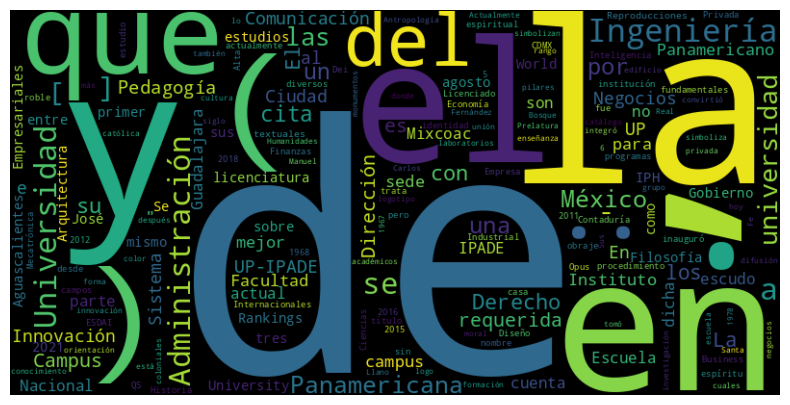

In [33]:
#Hacer grafica de wordcloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


# Compute Ebedding DOR

In [34]:
import math

def compute_dor(TR):
    DTR = np.zeros((TR.shape[1], TR.shape[0]), dtype=np.float64)
    tam_V = TR.shape[1]

    for doc, i in zip(TR, range(len(TR))):
        nonzero_positions = np.nonzero(doc)[0]  # Obtener índices de palabras presentes en el documento
        tam_v = len(nonzero_positions)  # Número de palabras presentes en el documento
        for term in nonzero_positions:
            DTR[term, i] = doc[term] * math.log(tam_V / tam_v) # Calcular DOR utilizando TF-IDF
    return DTR

In [35]:
DOR_base = compute_dor(BOW_tr)
DOR_base = preprocessing.normalize(DOR_base, norm='l2')

In [36]:
DOR_base.shape

(10000, 5278)

In [37]:
DOR_base

array([[0.        , 0.        , 0.        , ..., 0.        , 0.02642121,
        0.01511991],
       [0.01975012, 0.        , 0.02268697, ..., 0.01857586, 0.        ,
        0.01471648],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]], shape=(10000, 5278))

# Selección de Caracterisitcas  

In [38]:
from sklearn.feature_selection import SelectKBest, chi2

In [39]:
feats = SelectKBest(chi2, k=1000)
feats.fit(BOW_tr, tr_y)

,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function chi...x7ee8a84ab6a0>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",1000


In [40]:
best = feats.get_support(indices = True)

In [41]:
best

array([   1,    4,    5,    7,   10,   12,   17,   18,   19,   22,   24,
         25,   28,   30,   36,   37,   38,   39,   48,   50,   54,   56,
         57,   59,   61,   63,   64,   66,   67,   70,   71,   79,   86,
         88,   89,   92,   93,   94,  100,  102,  103,  104,  105,  107,
        111,  114,  115,  116,  119,  122,  123,  124,  128,  129,  131,
        133,  134,  136,  143,  147,  150,  153,  154,  166,  170,  177,
        178,  179,  182,  184,  191,  200,  209,  217,  221,  222,  225,
        230,  231,  236,  237,  245,  246,  248,  249,  250,  252,  257,
        264,  265,  266,  271,  273,  284,  285,  289,  291,  295,  298,
        301,  302,  304,  307,  308,  309,  312,  317,  319,  320,  322,
        332,  337,  352,  353,  357,  358,  366,  367,  369,  375,  389,
        390,  392,  393,  397,  402,  408,  417,  419,  423,  430,  434,
        438,  441,  445,  447,  458,  460,  461,  467,  469,  470,  472,
        474,  482,  483,  484,  490,  491,  492,  4

In [42]:
dict_indice_invertido = {v: k for k, v in dic_indices.items()}

In [43]:
target_words = [dict_indice_invertido[i] for i in best]
target_words

['de',
 'la',
 'a',
 '!',
 'me',
 'en',
 'verga',
 'los',
 'madre',
 '"',
 'te',
 'mi',
 'una',
 'putos',
 'su',
 'pero',
 'tu',
 'loca',
 '¿',
 'son',
 'cuando',
 ':',
 'yo',
 'porque',
 'está',
 'estoy',
 'sus',
 'esta',
 'puta',
 'pinche',
 'puto',
 'soy',
 'q',
 'mis',
 'joto',
 'cosas',
 '️',
 'vida',
 'vale',
 'quiero',
 'marica',
 'eres',
 'día',
 'esa',
 '😭',
 'mierda',
 '-',
 'tengo',
 'ese',
 'luchona',
 '😍',
 'hdp',
 '“',
 'tienen',
 'pinches',
 'tus',
 'tontas',
 '”',
 'hoy',
 'cagado',
 'puedo',
 'pendejo',
 'hijo',
 'alguien',
 'cabrona',
 'maricon',
 'vas',
 'mucho',
 '❤',
 'sé',
 'años',
 'hijos',
 'mundo',
 'días',
 'esos',
 'amor',
 'mamá',
 'tienes',
 'tiempo',
 'pendeja',
 'estaba',
 'siento',
 'mañana',
 'he',
 'd',
 'camote',
 'veo',
 'donde',
 ':(',
 'fotos',
 'cabrón',
 'buena',
 'trabajo',
 'culo',
 'casa',
 '😈',
 'valer',
 'chingar',
 'pendejos',
 'cara',
 '🤣',
 'mil',
 'noche',
 'mundial',
 'luego',
 'estos',
 '😩',
 'ustedes',
 'semana',
 'pueden',
 'gay',
 '

In [44]:
target_matrix = np.array([DOR_base[dic_indices[word]] for word in target_words])

In [45]:
target_matrix.shape

(1000, 5278)

In [46]:
# from tsne import tsne
from sklearn.manifold import TSNE

In [47]:
reduced_matrix = TSNE(n_components=2).fit_transform(target_matrix)

In [48]:
reduced_matrix.shape    

(1000, 2)

# Visualizar

In [49]:
max_x = np.max(reduced_matrix, axis=0)[0]
max_y = np.max(reduced_matrix, axis=0)[1]

In [50]:
max_x

np.float32(72.51003)

In [51]:
max_y

np.float32(70.365555)

/home/atzin/NLP/env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129315 (\N{ROLLING ON THE FLOOR LAUGHING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/atzin/NLP/env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127814 (\N{AUBERGINE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/atzin/NLP/env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128579 (\N{UPSIDE-DOWN FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/atzin/NLP/env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128556 (\N{GRIMACING FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/atzin/NLP/env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129316 (\N{DROOLING FACE}) missing from font(s) DejaVu Sans.
  fig.canva

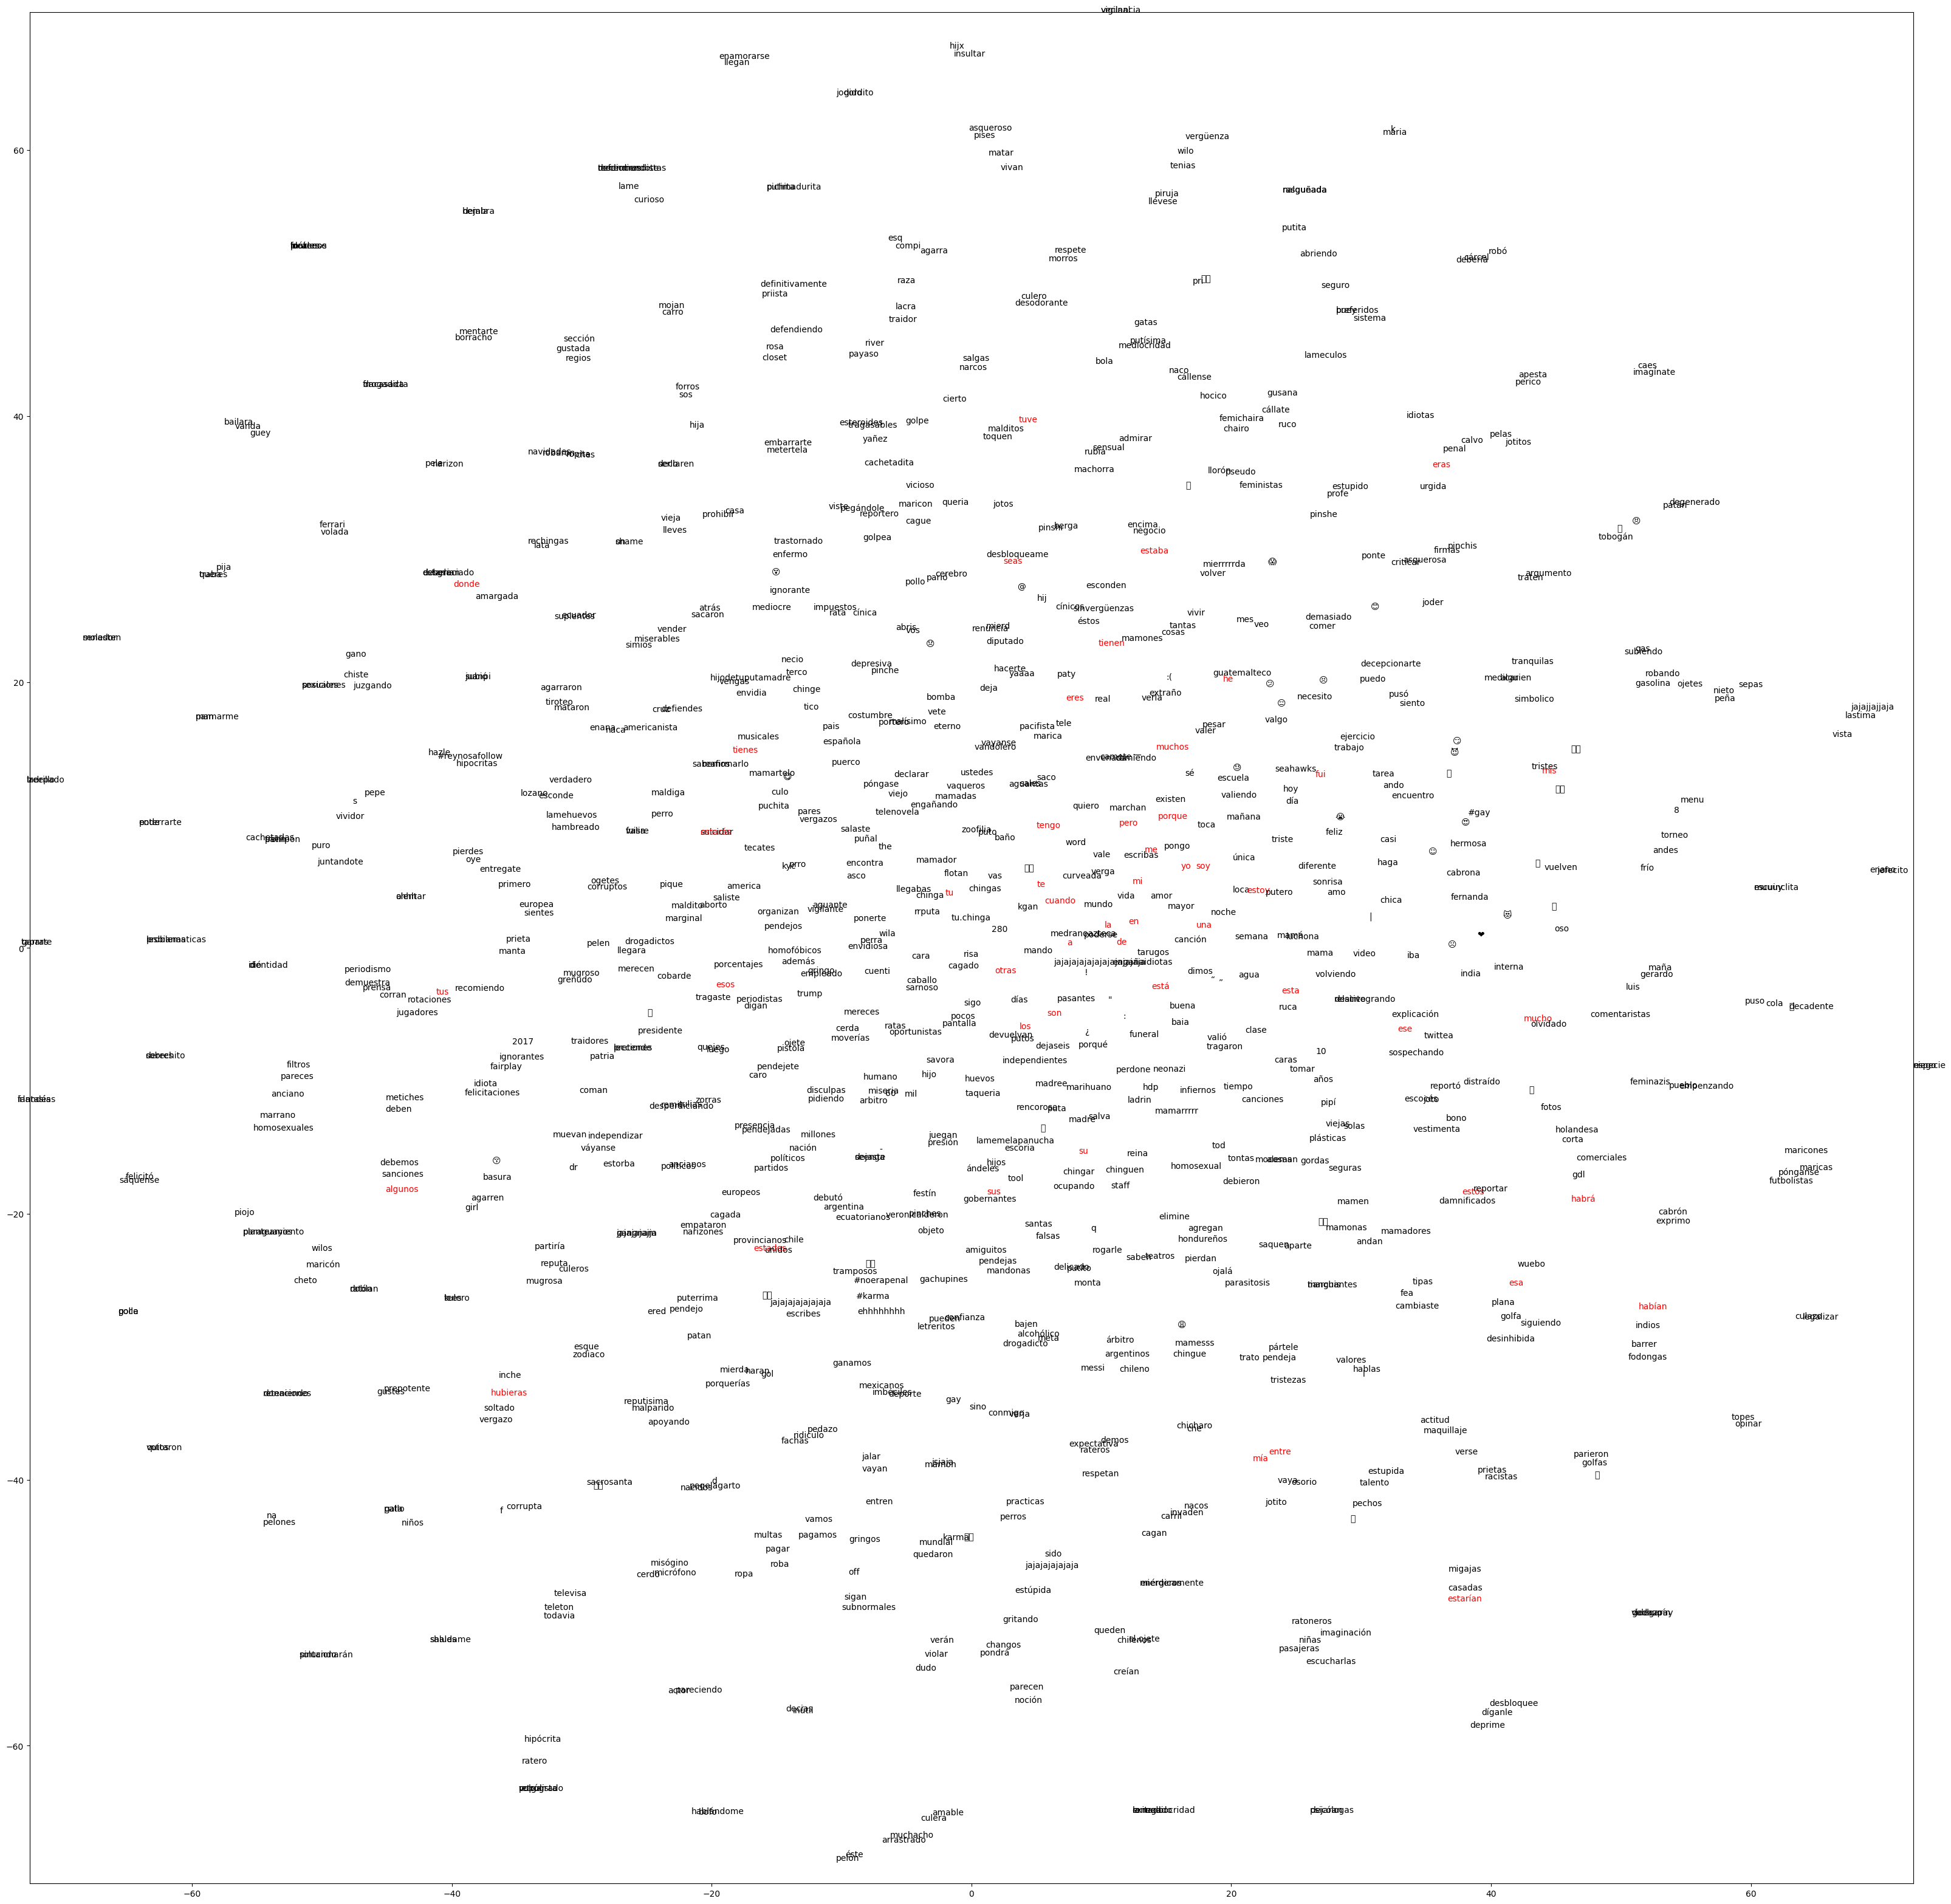

In [52]:
plt.figure(figsize=(40, 40), dpi = 100)

plt.xlim(-max_x, max_x)
plt.ylim(-max_y, max_y)

# Pintar las palabras
from nltk.corpus import stopwords
stop_words = set(stopwords.words('spanish'))

for i, word in enumerate(target_words):
    x = reduced_matrix[i, 0]
    y = reduced_matrix[i, 1]
    if word in stop_words:
        plt.text(x, y, word, color='red')  # Palabras vacías en rojo
    else:
        plt.text(x, y, word)

#escribe la palabra

plt.show()

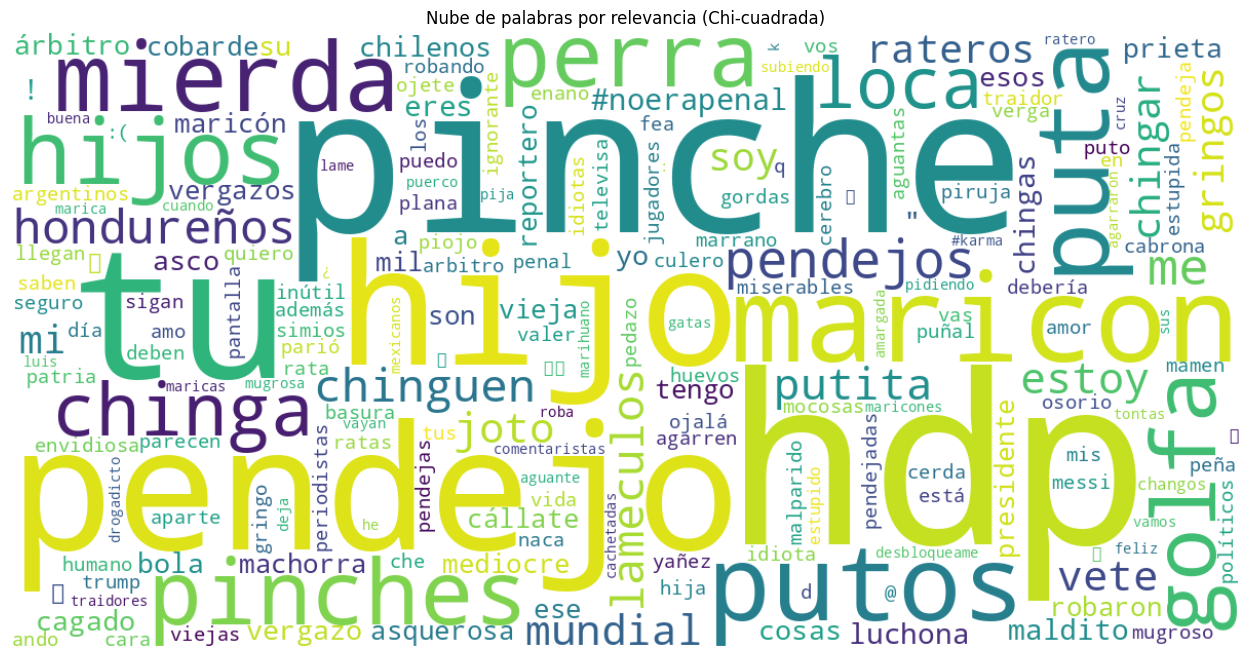

In [53]:
from wordcloud import WordCloud
import numpy as np
import matplotlib.pyplot as plt

scores = np.nan_to_num(feats.scores_, nan=0.0, posinf=0.0, neginf=0.0)

relevance = {}
for idx in best:
    word = dict_indice_invertido[idx]
    score = float(scores[idx])
    if score > 0:
        relevance[word] = score

top_n = 200
relevance_top = dict(sorted(relevance.items(), key=lambda x: x[1], reverse=True)[:top_n])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='viridis'
).generate_from_frequencies(relevance_top)

plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de palabras por relevancia (Chi-cuadrada)')
plt.show()

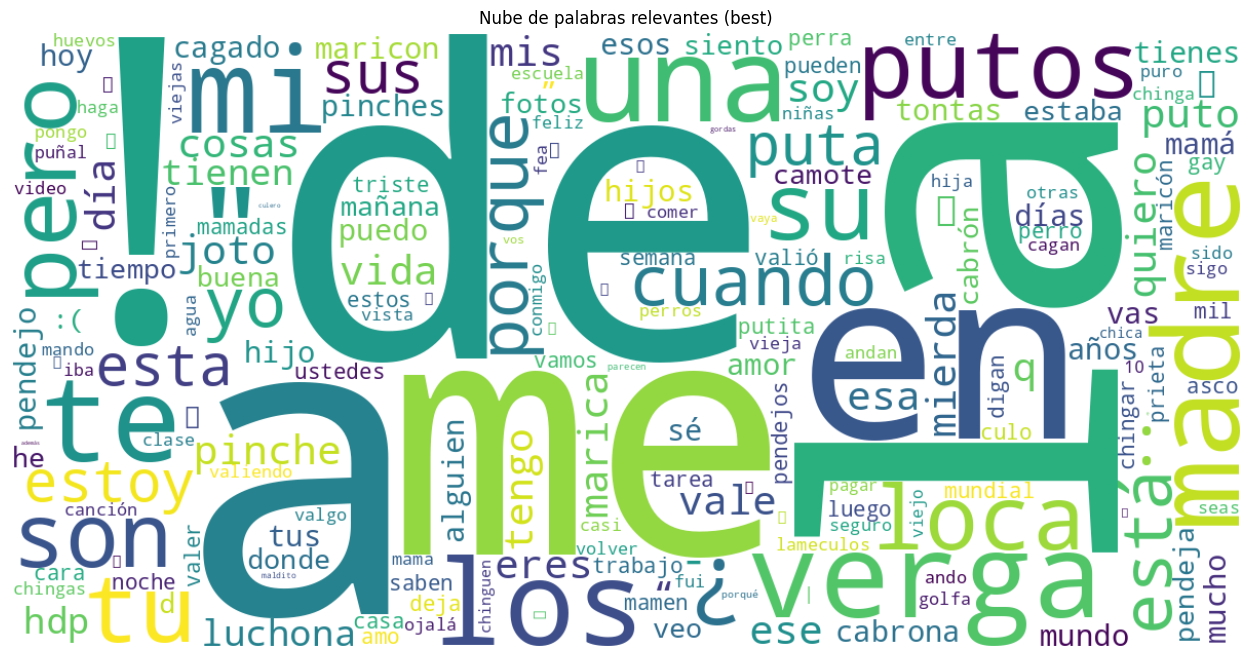

In [54]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Usar directamente las palabras seleccionadas en best
target_words_best = [dict_indice_invertido[idx] for idx in best]

top_n = 200
target_words_best = target_words_best[:top_n]

# Peso por ranking para que las primeras aparezcan más grandes
relevance_top = {word: (top_n - i) for i, word in enumerate(target_words_best)}

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='viridis'
).generate_from_frequencies(relevance_top)

plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de palabras relevantes (best)')
plt.show()

In [55]:
relevance_top

{'de': 200,
 'la': 199,
 'a': 198,
 '!': 197,
 'me': 196,
 'en': 195,
 'verga': 194,
 'los': 193,
 'madre': 192,
 '"': 191,
 'te': 190,
 'mi': 189,
 'una': 188,
 'putos': 187,
 'su': 186,
 'pero': 185,
 'tu': 184,
 'loca': 183,
 '¿': 182,
 'son': 181,
 'cuando': 180,
 ':': 179,
 'yo': 178,
 'porque': 177,
 'está': 176,
 'estoy': 175,
 'sus': 174,
 'esta': 173,
 'puta': 172,
 'pinche': 171,
 'puto': 170,
 'soy': 169,
 'q': 168,
 'mis': 167,
 'joto': 166,
 'cosas': 165,
 '️': 164,
 'vida': 163,
 'vale': 162,
 'quiero': 161,
 'marica': 160,
 'eres': 159,
 'día': 158,
 'esa': 157,
 '😭': 156,
 'mierda': 155,
 '-': 154,
 'tengo': 153,
 'ese': 152,
 'luchona': 151,
 '😍': 150,
 'hdp': 149,
 '“': 148,
 'tienen': 147,
 'pinches': 146,
 'tus': 145,
 'tontas': 144,
 '”': 143,
 'hoy': 142,
 'cagado': 141,
 'puedo': 140,
 'pendejo': 139,
 'hijo': 138,
 'alguien': 137,
 'cabrona': 136,
 'maricon': 135,
 'vas': 134,
 'mucho': 133,
 '❤': 132,
 'sé': 131,
 'años': 130,
 'hijos': 129,
 'mundo': 128,
 'dí

# Vectores de palabras y semantica vectorial

In [56]:
t_words = target_words
subsetwords = ["politicos", "corrupción", "PRI", "feliz", "hermosa", "chica", "tu", "hdp", "madre", "madres", "@usuario", "hijos", "pendeja", "pendejo", "mierda", "loca", "hijo", "hija", "mamá", "tia"]

In [57]:
subreduced_matrix = []
ploted_subsetwords = []
for idx, word in enumerate(t_words[:]):
    if word in subsetwords:
        ploted_subsetwords += [word]
        subreduced_matrix += [reduced_matrix[idx]]

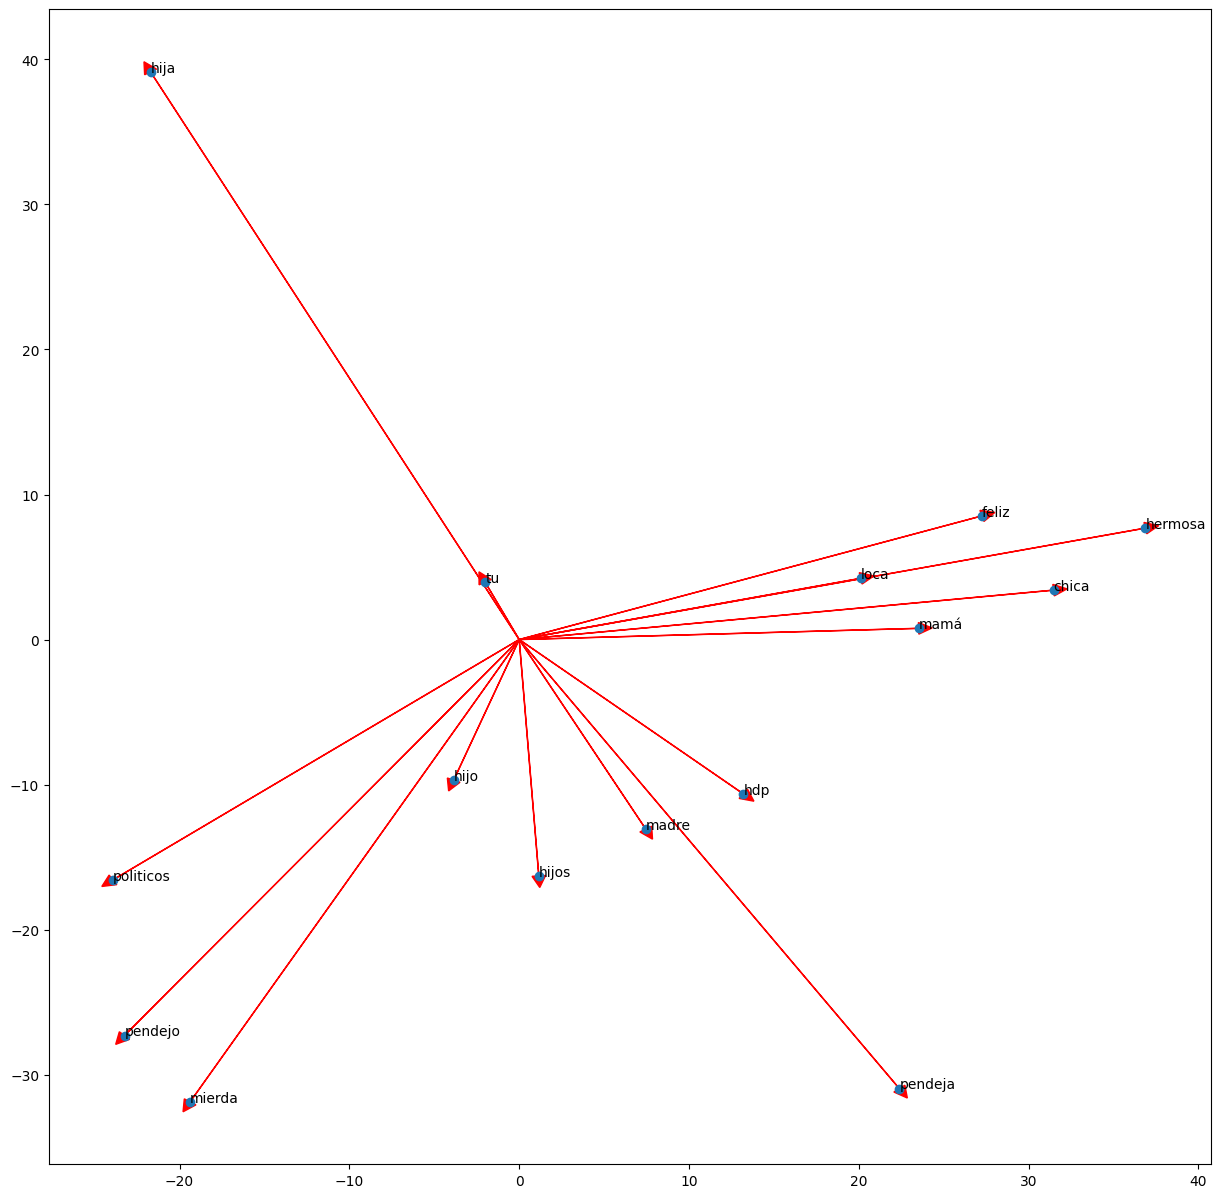

In [58]:
subreduced_matrix = np.array(subreduced_matrix)

fig, ax = plt.subplots(figsize = (15, 15))

col1 = 0
col2 = 1

for word in subreduced_matrix:
    ax.arrow(0, 0, word[col1], word[col2], head_width=0.8, head_length=0.8, fc='r', ec='r', width = 1e-2)
ax.scatter(subreduced_matrix[:,col1], subreduced_matrix[:,col2]) 

for i in range(0, len(ploted_subsetwords)):
    ax.annotate(ploted_subsetwords[i], (subreduced_matrix[i,col1], subreduced_matrix[i,col2]))
    
plt.show()

In [59]:
def build_cooc_tr(texts, dict_indices, tokenizer):
    import numpy as np
    cooc = np.zeros((len(dict_indices), len(dict_indices)), dtype=np.int32)

    for doc in texts:
        tokens = tokenizer.tokenize(doc.lower())
        tokens = [w for w in tokens if w in dict_indices]
        unique_tokens = list(set(tokens))
        indices = [dict_indices[w] for w in unique_tokens]

        # Diagonal: número de tuits donde aparece la palabra
        for wi in indices:
            cooc[wi, wi] += 1

        # Fuera de diagonal: pares de palabras que coaparecen en el mismo tuit
        for i in range(len(indices)):
            wi = indices[i]
            for j in range(i + 1, len(indices)):
                wj = indices[j]
                cooc[wi, wj] += 1
                cooc[wj, wi] += 1

    return cooc

# Matriz palabra x palabra usando solo 5000 tuits
COOC_tr = build_cooc_tr(tr_text[:5000], dic_indices, tokenizer)
COOC_tr.shape

(10000, 10000)

In [60]:
import numpy as np
np.set_printoptions(suppress=True)
print(COOC_tr)

[[1990  934  895 ...    1    0    1]
 [ 934 2226  982 ...    1    0    0]
 [ 895  982 2176 ...    0    0    1]
 ...
 [   1    1    0 ...    1    0    0]
 [   0    0    0 ...    0    1    0]
 [   1    0    1 ...    0    0    1]]


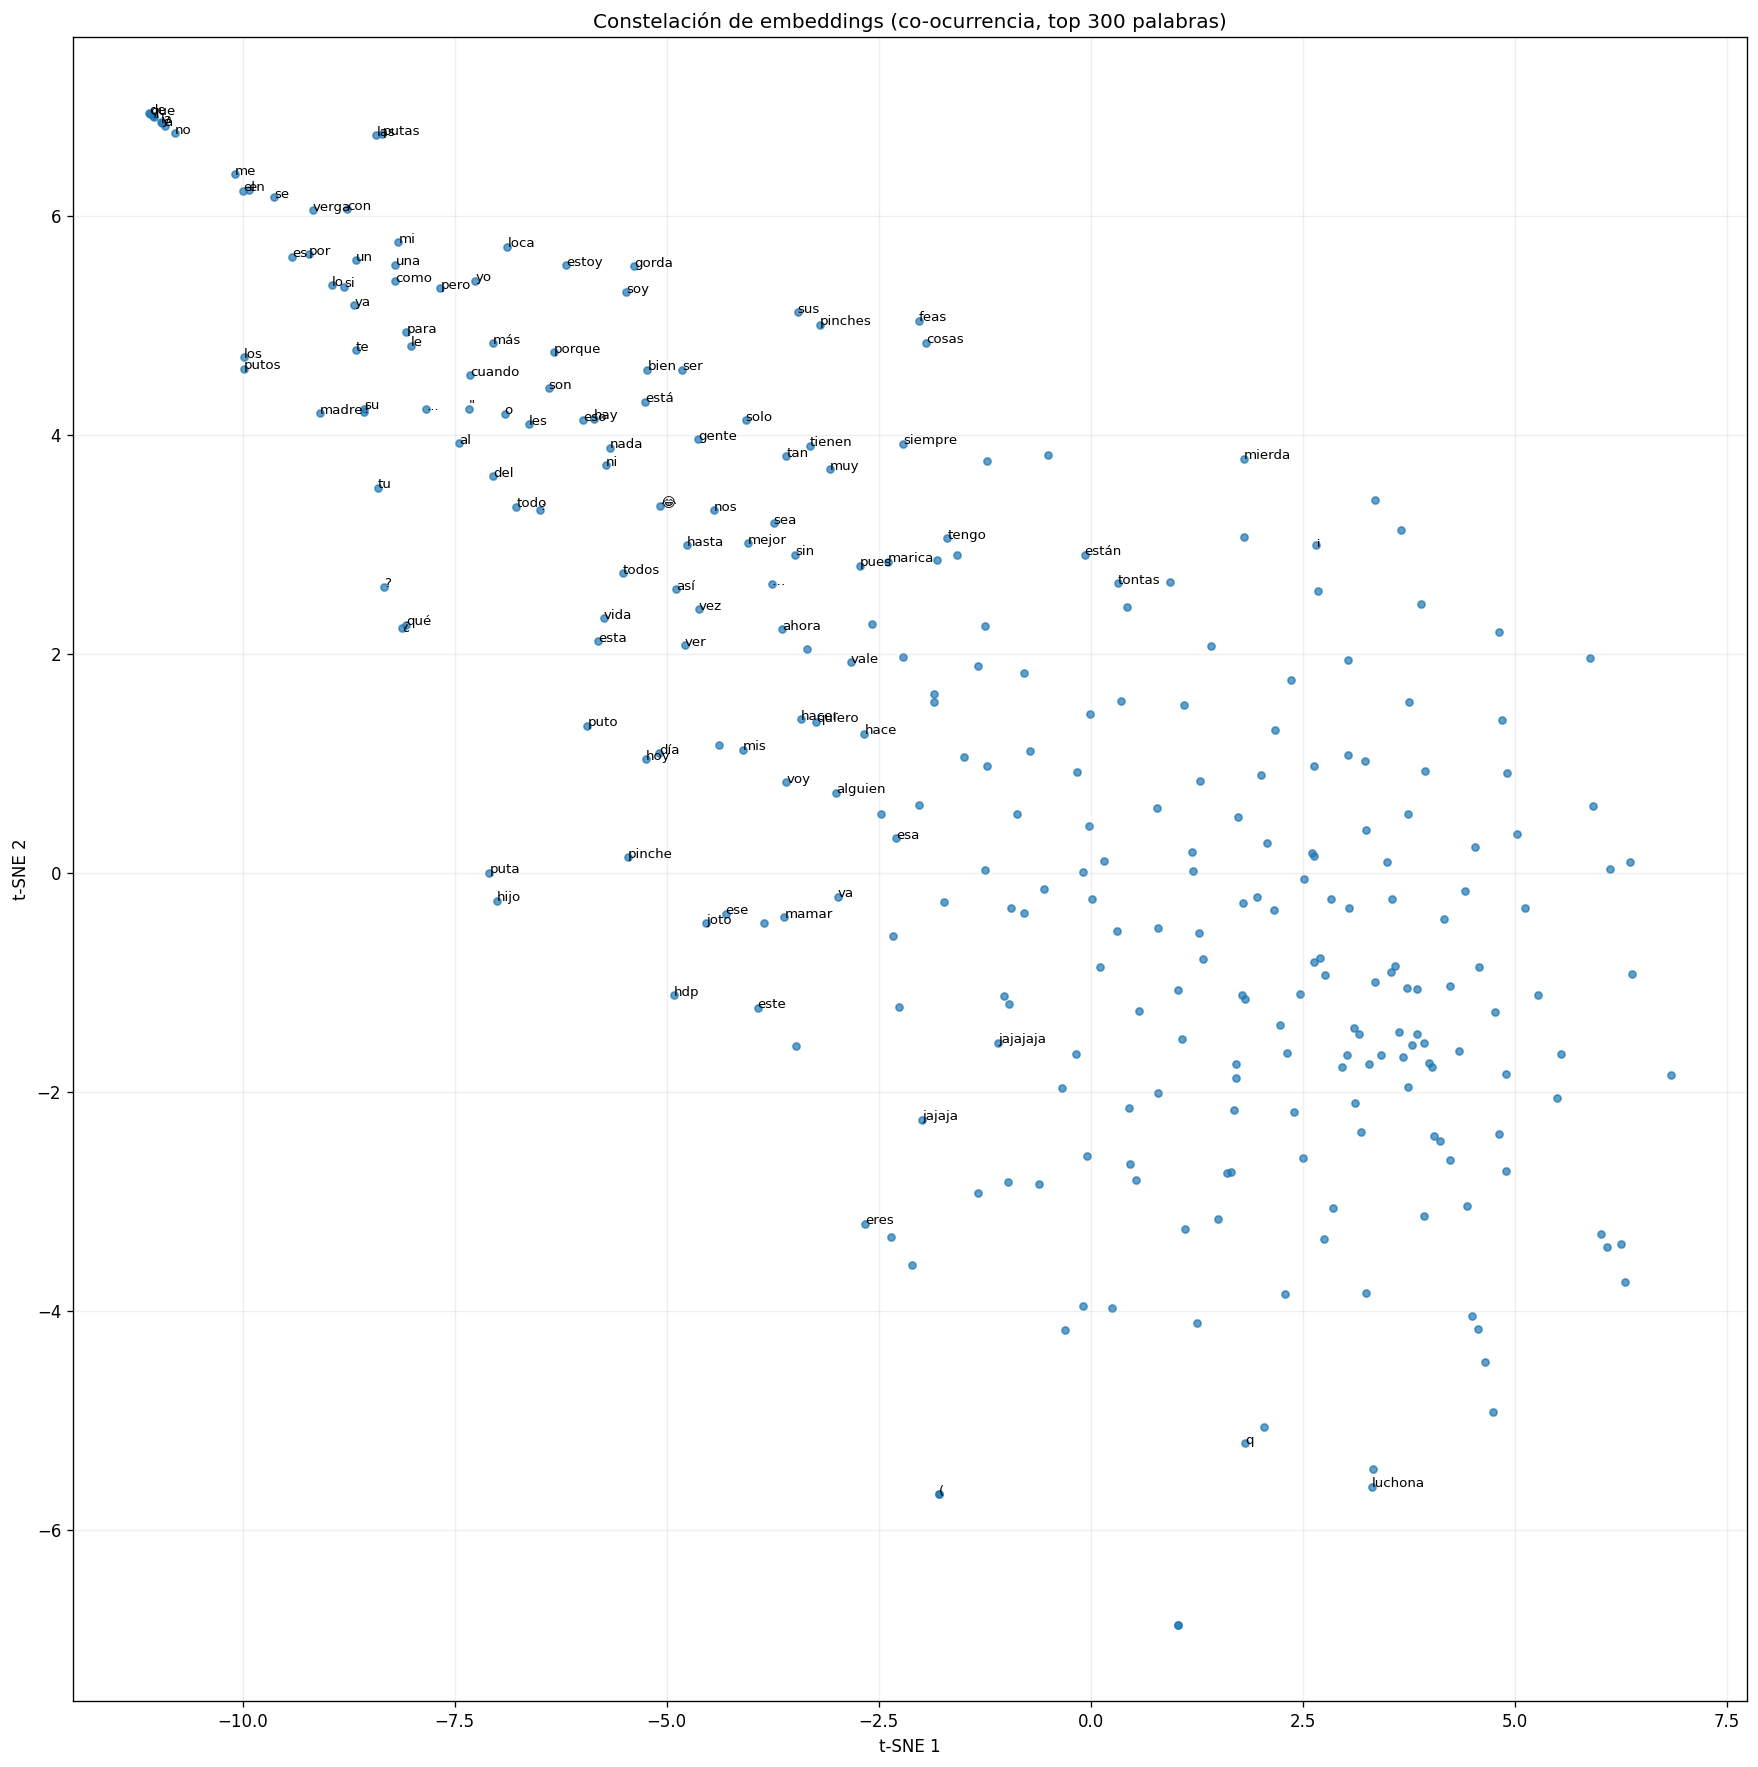

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Embedding por palabra: cada fila de COOC_tr
doc_freq = np.diag(COOC_tr)
top_words = 300  # reducir para que t-SNE sea manejable
selected_idx = np.argsort(doc_freq)[::-1][:top_words]

emb_matrix = COOC_tr[selected_idx, :]
labels = [dict_indice_invertido[i] for i in selected_idx]

reduced_emb = TSNE(
    n_components=2,
    init='pca',
    learning_rate='auto',
    random_state=42
).fit_transform(emb_matrix)

plt.figure(figsize=(18, 18), dpi=120)
plt.scatter(reduced_emb[:, 0], reduced_emb[:, 1], s=18, alpha=0.7)

# Etiquetar una parte para evitar saturación visual
for i, word in enumerate(labels[:120]):
    plt.text(reduced_emb[i, 0], reduced_emb[i, 1], word, fontsize=8)

plt.title('Constelación de embeddings (co-ocurrencia, top 300 palabras)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.grid(alpha=0.2)
plt.show()

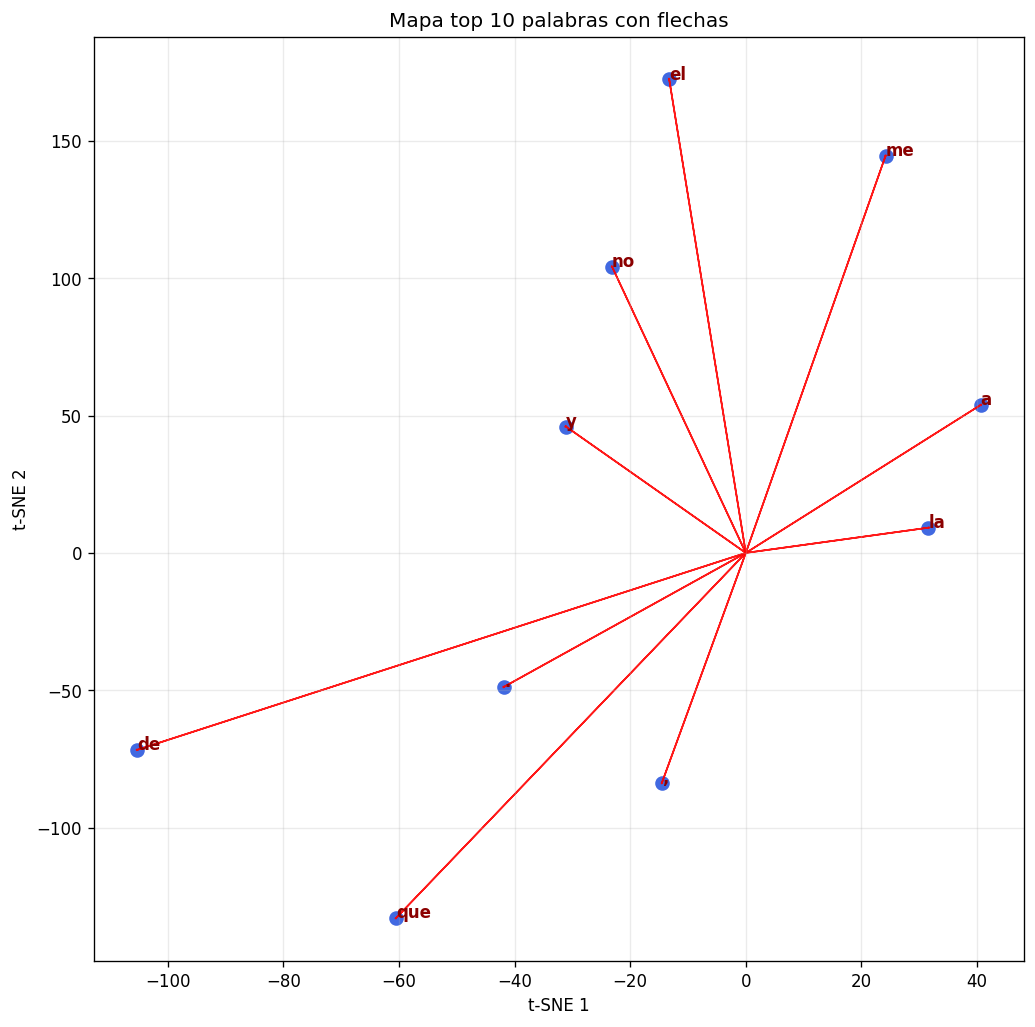

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Mapa separado: solo top 10 palabras
doc_freq = np.diag(COOC_tr)
top10_idx = np.argsort(doc_freq)[::-1][:10]
top10_labels = [dict_indice_invertido[i] for i in top10_idx]

top10_matrix = COOC_tr[top10_idx, :]
top10_emb = TSNE(
    n_components=2,
    init='pca',
    learning_rate='auto',
    random_state=42,
    perplexity=5
).fit_transform(top10_matrix)

plt.figure(figsize=(10, 10), dpi=120)
plt.scatter(top10_emb[:, 0], top10_emb[:, 1], s=60, color='royalblue')

for i, word in enumerate(top10_labels):
    x, y = top10_emb[i, 0], top10_emb[i, 1]
    plt.arrow(0, 0, x, y, head_width=0.25, head_length=0.25, fc='red', ec='red', width=0.0025, alpha=0.9)
    plt.text(x, y, word, color='darkred', fontsize=10, fontweight='bold')

plt.title('Mapa top 10 palabras con flechas')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.grid(alpha=0.25)
plt.show()